## Challenge 03 – Redes Neuronales con MLPClassifier
**Nombre:** Victor Misael Escalante Alvarado, A01741176  
**Dataset:** Wine Recognition Data  

---
Se implementan dos redes neuronales (MLPClassifier de scikit-learn) sobre el dataset de vinos:  
- **NN1:** Una característica relevante (`flavanoids`), una capa oculta con **2 neuronas**.  
- **NN2:** Todas las características (13), dos capas ocultas con **64 y 32 neuronas** respectivamente.  

Se generan matrices de confusión, se comparan ambas redes y se contrastan con el mejor clasificador logístico del Challenge 02.

## Librerías

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 6)
sns.set_theme(style='whitegrid', palette='muted')

## Directorios de resultados

In [3]:
RESULTS_DIR = Path('results')
IMAGES_DIR  = RESULTS_DIR / 'images'
TABLES_DIR  = RESULTS_DIR / 'tables'

for d in [IMAGES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

## Carga y exploración del dataset

In [4]:
column_names = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline'
]

df = pd.read_csv('data/wine.data', header=None, names=column_names)

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nDistribución de clases:')
print(df['class'].value_counts().sort_index().to_string())
df.head()

Dimensiones del dataset: (178, 14)

Distribución de clases:
class
1    59
2    71
3    48


,class,alcohol,malic_acid,ash,alcalinity_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Justificación de la característica seleccionada para NN1

En el **Challenge 02** se calculó la correlación absoluta de cada característica con la clase objetivo. `flavanoids` obtuvo la correlación más alta (≈ 0.847), siendo el mejor discriminador individual entre las tres clases de vino. Por ello se utiliza como única entrada de NN1.

## Preparación de datos

In [5]:
RANDOM_STATE = 42
TEST_SIZE    = 0.2

FEATURE_COLS_ALL = [
    'alcohol', 'malic_acid', 'ash', 'alcalinity_ash', 'magnesium',
    'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline'
]

y = df['class'].values

def prepare_data(feature_cols):
    X = df[feature_cols].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    return X_train_s, X_test_s, y_train, y_test

# NN1: solo flavanoids
X_tr1, X_te1, y_tr1, y_te1 = prepare_data(['flavanoids'])

# NN2: todas las características
X_tr2, X_te2, y_tr2, y_te2 = prepare_data(FEATURE_COLS_ALL)

# Logistic Regression baseline (flavanoids, igual que mejor modelo Ch02)
X_tr_lr, X_te_lr, y_tr_lr, y_te_lr = prepare_data(['flavanoids'])

print(f'Muestras totales : {len(y)}')
print(f'Train            : {len(y_tr1)}')
print(f'Test             : {len(y_te1)}')

Muestras totales : 178
Train            : 142
Test             : 36


## NN1 — 1 característica (`flavanoids`), 1 capa oculta (2 neuronas)

In [6]:
nn1 = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=RANDOM_STATE
)
nn1.fit(X_tr1, y_tr1)
y_pred_nn1 = nn1.predict(X_te1)
acc_nn1 = accuracy_score(y_te1, y_pred_nn1)

print('=== NN1: flavanoids | hidden=(2,) ===')
print(f'Accuracy : {acc_nn1:.4f}')
print()
print(classification_report(y_te1, y_pred_nn1, target_names=['Clase 1','Clase 2','Clase 3']))

=== NN1: flavanoids | hidden=(2,) ===
Accuracy : 0.8333

              precision    recall  f1-score   support

     Clase 1       0.79      0.92      0.85        12
     Clase 2       0.83      0.71      0.77        14
     Clase 3       0.90      0.90      0.90        10

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.84        36
weighted avg       0.84      0.83      0.83        36



## NN2 — Todas las características (13), 2 capas ocultas (64 y 32 neuronas)

Se eligió la arquitectura **(64, 32)** por las siguientes razones:
- La primera capa (64 neuronas) tiene capacidad suficiente para capturar interacciones no lineales entre las 13 entradas.
- La segunda capa (32 neuronas) actúa como cuello de botella que extrae representaciones más abstractas antes de la clasificación final.
- Dado el tamaño pequeño del dataset (178 muestras), capas más grandes aumentarían el riesgo de sobreajuste.

In [7]:
nn2 = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=RANDOM_STATE
)
nn2.fit(X_tr2, y_tr2)
y_pred_nn2 = nn2.predict(X_te2)
acc_nn2 = accuracy_score(y_te2, y_pred_nn2)

print('=== NN2: todas las features | hidden=(64, 32) ===')
print(f'Accuracy : {acc_nn2:.4f}')
print()
print(classification_report(y_te2, y_pred_nn2, target_names=['Clase 1','Clase 2','Clase 3']))

=== NN2: todas las features | hidden=(64, 32) ===
Accuracy : 0.9722

              precision    recall  f1-score   support

     Clase 1       1.00      1.00      1.00        12
     Clase 2       0.93      1.00      0.97        14
     Clase 3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## Baseline — Mejor modelo de Regresión Logística (Challenge 02)

El mejor modelo del Challenge 02 usó `flavanoids` como única característica y alcanzó **accuracy = 0.8333**. Se re-entrena aquí con los mismos parámetros para una comparación directa.

In [8]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_tr_lr, y_tr_lr)
y_pred_lr = lr.predict(X_te_lr)
acc_lr = accuracy_score(y_te_lr, y_pred_lr)

print('=== Regresión Logística (flavanoids) — baseline Ch02 ===')
print(f'Accuracy : {acc_lr:.4f}')
print()
print(classification_report(y_te_lr, y_pred_lr, target_names=['Clase 1','Clase 2','Clase 3']))

=== Regresión Logística (flavanoids) — baseline Ch02 ===
Accuracy : 0.8333

              precision    recall  f1-score   support

     Clase 1       0.79      0.92      0.85        12
     Clase 2       0.83      0.71      0.77        14
     Clase 3       0.90      0.90      0.90        10

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.84        36
weighted avg       0.84      0.83      0.83        36



## Matrices de Confusión

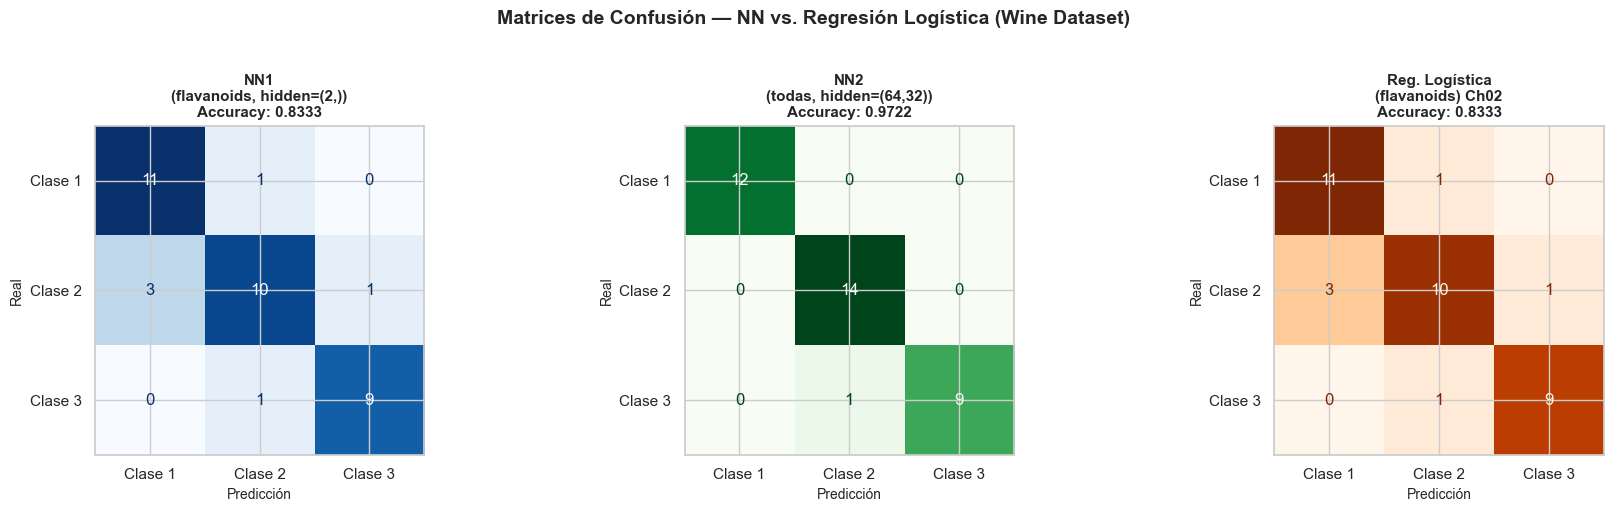

Guardado en: results/images/confusion_matrices_nn.png


In [9]:
class_labels = ['Clase 1', 'Clase 2', 'Clase 3']

models_info = [
    ('NN1\n(flavanoids, hidden=(2,))',      y_te1,   y_pred_nn1, acc_nn1,  'Blues'),
    ('NN2\n(todas, hidden=(64,32))',         y_te2,   y_pred_nn2, acc_nn2,  'Greens'),
    ('Reg. Logística\n(flavanoids) Ch02',   y_te_lr, y_pred_lr,  acc_lr,   'Oranges'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — NN vs. Regresión Logística (Wine Dataset)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (title, y_true, y_pred, acc, cmap) in zip(axes, models_info):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'confusion_matrices_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado en: {IMAGES_DIR}/confusion_matrices_nn.png')

## Comparación de Accuracy

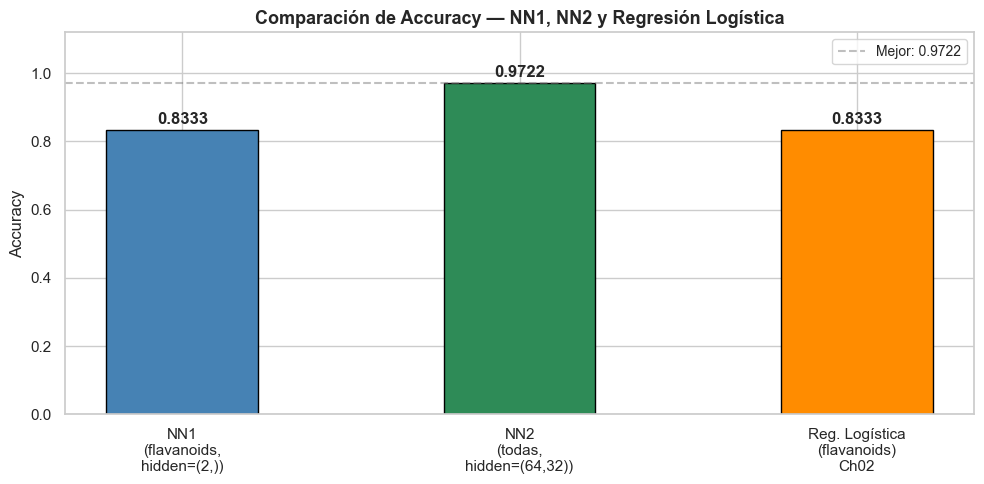

Guardado en: results/images/accuracy_comparison_nn.png


In [10]:
labels     = ['NN1\n(flavanoids,\nhidden=(2,))', 'NN2\n(todas,\nhidden=(64,32))', 'Reg. Logística\n(flavanoids)\nCh02']
accs       = [acc_nn1, acc_nn2, acc_lr]
bar_colors = ['steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, accs, color=bar_colors, edgecolor='black', width=0.45)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Accuracy — NN1, NN2 y Regresión Logística', fontsize=13, fontweight='bold')
ax.axhline(y=max(accs), color='gray', linestyle='--', alpha=0.5, label=f'Mejor: {max(accs):.4f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'accuracy_comparison_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado en: {IMAGES_DIR}/accuracy_comparison_nn.png')

## Tabla Comparativa de Métricas

In [11]:
summary_data = []
for title, y_true, y_pred, acc, _ in models_info:
    label  = title.replace('\n', ' ')
    report = classification_report(y_true, y_pred,
                                   target_names=class_labels, output_dict=True)
    summary_data.append({
        'Modelo'          : label,
        'Accuracy'        : round(acc, 4),
        'Precision_macro' : round(report['macro avg']['precision'], 4),
        'Recall_macro'    : round(report['macro avg']['recall'],    4),
        'F1_macro'        : round(report['macro avg']['f1-score'],  4),
    })

summary_df = pd.DataFrame(summary_data)
csv_path   = TABLES_DIR / 'resumen_metricas_nn.csv'
summary_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

print('RESUMEN COMPARATIVO DE MODELOS')
print()
print(summary_df.to_string(index=False))
print(f'\nTabla exportada a: {csv_path}')

RESUMEN COMPARATIVO DE MODELOS

                          Modelo  Accuracy  Precision_macro  Recall_macro  F1_macro
   NN1 (flavanoids, hidden=(2,))    0.8333           0.8397        0.8437    0.8385
     NN2 (todas, hidden=(64,32))    0.9722           0.9778        0.9667    0.9710
Reg. Logística (flavanoids) Ch02    0.8333           0.8397        0.8437    0.8385

Tabla exportada a: results/tables/resumen_metricas_nn.csv


## Curva de Pérdida durante el entrenamiento

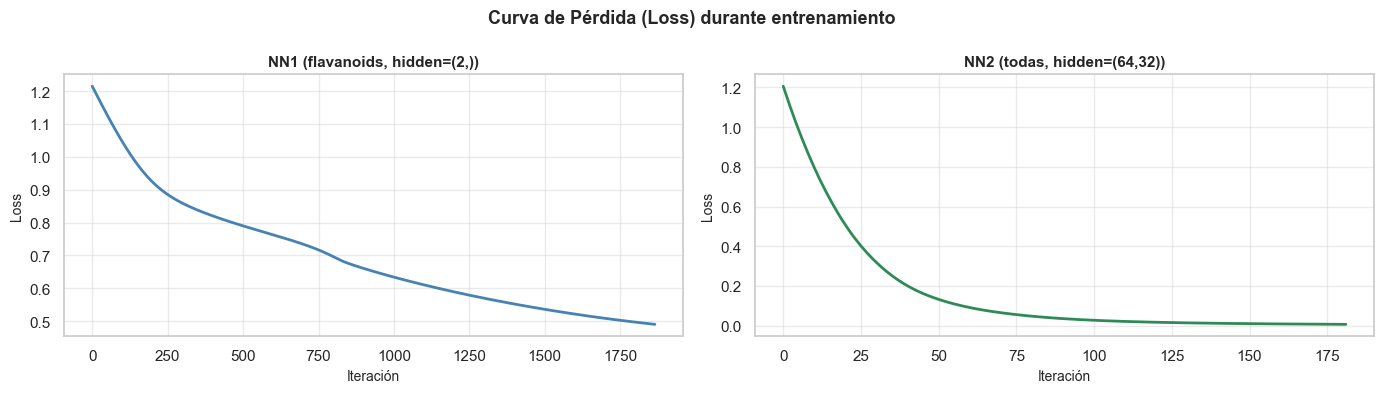

Guardado en: results/images/loss_curves_nn.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Curva de Pérdida (Loss) durante entrenamiento', fontsize=13, fontweight='bold')

for ax, model, title, color in zip(
    axes,
    [nn1, nn2],
    ['NN1 (flavanoids, hidden=(2,))', 'NN2 (todas, hidden=(64,32))'],
    ['steelblue', 'seagreen']
):
    ax.plot(model.loss_curve_, color=color, linewidth=2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Iteración', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'loss_curves_nn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado en: {IMAGES_DIR}/loss_curves_nn.png')

## Análisis y Conclusiones

### ¿Cuál red se desempeña mejor?

| Modelo | Features | Arquitectura | Accuracy |
|--------|----------|-------------|----------|
| NN1 | flavanoids (1) | hidden=(2,) | 0.8333 |
| NN2 | todas (13) | hidden=(64, 32) | **0.9722** |
| Reg. Logística (Ch02) | flavanoids (1) | — | 0.8333 |

**NN2** supera claramente a NN1 y al clasificador logístico. Con las 13 características y arquitectura (64, 32) alcanza un **accuracy de 0.9722** (35/36 predicciones correctas). NN1, con solo 2 neuronas y 1 entrada, empata exactamente con la regresión logística del Challenge 02 en 0.8333, lo que demuestra que la capacidad del modelo es el factor limitante cuando la información de entrada es escasa.

### ¿Son útiles las redes neuronales para este problema?

Sí, especialmente NN2. El dataset de vinos tiene 3 clases con fronteras de decisión no perfectamente lineales en el espacio completo de 13 características. Una MLP con suficiente capacidad captura estas no linealidades, lo que se refleja en la mejora de casi **14 puntos porcentuales** respecto a la regresión logística (0.9722 vs 0.8333). Sin embargo, dado el tamaño pequeño del dataset (178 muestras), es importante no sobredimensionar la arquitectura; (64, 32) es un balance razonable entre capacidad y generalización.

NN1 confirma que usar redes neuronales con información insuficiente no ofrece ventaja sobre modelos lineales. La ganancia de las NNs proviene de la combinación entre **profundidad, ancho y variedad de features**.

### Comparación contra el mejor clasificador logístico (Challenge 02)

- **Regresión Logística (flavanoids):** 0.8333 — buen baseline, limitado por la linealidad y por usar solo 1 feature.
- **NN1 (flavanoids, 2 neuronas):** 0.8333 — igual rendimiento; con tan pocas neuronas y 1 variable no se supera el umbral lineal.
- **NN2 (todas las features, 64+32):** **0.9722** — mejor modelo. Aprovecha la riqueza del dataset y las no linealidades de la red.

**Conclusión:** NN2 es el modelo más poderoso. La ventaja de las redes neuronales sobre la regresión logística se materializa únicamente cuando se les proporciona suficiente información (todas las features) y arquitectura adecuada.